> **경고 - 이 노트북은 공유 환경에 부작용을 남긴다.**
> 모드마다 `advance_rag_project_epoch(1)` 을 호출해 **프로젝트 1번의 답변 캐시를
> 전부 무효화한다.** 캐시 히트를 0으로 만들어야 백엔드별 점수가 나오기 때문인데,
> 그 대가로 같은 DB 를 보는 사람들의 답변이 한동안 느려진다(캐시 재구축).
> 실제 DB 와 외부 생성 API 도 그대로 호출한다 - 30문항 x 3모드 = 90회다.
> 운영과 같은 DB 를 가리킨 채 무심코 돌리지 말 것.

# 어시스턴트 답변 품질 베이스라인 측정

**목적**: 어시스턴트(RAG) 가 지금 어떤 답을 내고 있는지를 생성 백엔드별로 실측해 기준점을
만든다. 이후 프롬프트·검색을 고치는 작업은 이 숫자와의 차이로 판단한다.

**무엇을 재는가** — 축이 셋이고, 서로 합치지 않는다.

| 축 | 채점기 | 뜻 | LLM |
|---|---|---|---|
| 근거(grounding) | `tests/assistant_eval/scorer.py` | 사실마다 그 사실을 품은 출처가 실제로 검색에 올라왔는가 | 불필요(결정적) |
| 충실도(coverage) | `tests/assistant_eval/judge.py` | 답변이 `must_include_facts` 를 담았는가 | 필요 |
| 안전성(safety) | `tests/assistant_eval/judge.py` | 답변이 `must_not_claim` 을 하지 않았는가 | 필요 |

`faithfulness = coverage x safety` 는 심사기가 쓰는 정의를 그대로 따른다(평균이 아니라 곱인
이유는 `judge.py` docstring - 아무 말도 안 한 답변이 안전성만으로 점수를 받는 것을 막는다).
근거 축은 여기에 섞지 않는다. 실패 방향이 다른 값을 하나로 뭉개면 서로를 가린다.

**평가셋**: `App/backend_fastapi/tests/fixtures/assistant_eval/` 30건
(identifier 10 / semantic 10 / mixed 10). 프로젝트 1번 데이터(document_chunks 308건) 위에서
묻는다.

**백엔드를 나눠 재는 이유**: 생성 체인은 HuggingFace -> Gemini -> Ollama 로 조용히
내려앉는다(`generation_service._FALLBACK_CHAIN`). 폴백으로 답한 케이스와 HF 가 답한 케이스를
한 평균에 섞으면 그 평균은 어느 백엔드의 품질도 아니다. 그래서 `RAG_PROVIDER` 로 백엔드를
못 박아 따로 돌리고, 못 박지 않은 자동 모드(`auto`)를 한 열 더 둔다 - 운영이 실제로 타는
경로가 그것이다.

**한계** (숫자를 읽기 전에)

- 합성 평가셋 30건이다. 절대값에 통계적 의미를 두지 말고 before/after 차이로만 쓴다.
- 충실도·안전성은 LLM 심사(Qwen3-4B)다. 모델·프롬프트가 바뀌면 같은 답변도 점수가 흔들린다.
  `unparsed` 문항 수를 함께 본다 - 그 값이 크면 아래 점수를 믿으면 안 된다.
- 심사 모델(Qwen3-4B)은 HF 생성 티어와 같은 모델이다. `huggingface`/`auto` 열의 충실도·
  안전성은 자기평가다. 회의록 하네스(`03`)가 같은 이유로 같은 선택을 했다.
- 근거 축은 "답변이 인용했는가"가 아니라 "그 사실을 품은 출처가 검색에 올라왔는가"다.
  운영 프롬프트가 인용 표기를 요구하지 않기 때문이며, 이유 전문은 `scorer.py` docstring 에 있다.
  따라서 근거 축은 사실상 검색기 품질이고, 생성 백엔드를 바꿔도 거의 움직이지 않아야 정상이다.
- 답변 캐시(Redis, TTL 30분)를 그대로 두면 두 번째 실행부터 `provider="cache"` 가 섞여
  생성 품질이 아니라 캐시 재생을 재게 된다. 아래에서 프로젝트 캐시 epoch 를 올려 무효화한 뒤
  측정하고, 그래도 `cache` 가 관측되면 표에 드러낸다.

## 1. 준비

살아 있는 DB(프로젝트 1번 데이터)와 생성 백엔드가 있어야 돌아간다. 설정은 `App/.env` 에서
읽으며, 그 파일이 다른 곳에 있으면(예: git worktree 에서 실행) `ASSISTANT_EVAL_ENV_FILE`
환경변수로 경로를 준다.

In [1]:
import os
import sys
import time
from pathlib import Path

from dotenv import load_dotenv


# 노트북이 docs/notebooks/ 아래에 있어 cwd 가 저장소 루트가 아니다.
# `App/` 이 보이는 상위 디렉터리까지 거슬러 올라가 루트를 찾는다.
def _find_repo_root(marker: str = "App") -> Path:
    here = Path.cwd()
    for candidate in (here, *here.parents):
        if (candidate / marker).is_dir():
            return candidate
    raise RuntimeError(f"저장소 루트를 찾지 못했습니다 (현재: {here})")


REPO_ROOT = _find_repo_root()
BACKEND_DIR = REPO_ROOT / "App" / "backend_fastapi"
sys.path.insert(0, str(BACKEND_DIR))

# 설정은 `App/.env` 에 있고 이 파일은 추적되지 않는다. git worktree 에서 실행하면 워크트리
# 쪽에는 그 파일이 없으므로, 다른 경로를 쓰려면 ASSISTANT_EVAL_ENV_FILE 로 알려준다.
ENV_FILE = Path(os.getenv("ASSISTANT_EVAL_ENV_FILE") or (REPO_ROOT / "App" / ".env"))
if not ENV_FILE.is_file():
    raise RuntimeError(
        f"환경 파일을 찾지 못했습니다: {ENV_FILE}. "
        "ASSISTANT_EVAL_ENV_FILE 에 App/.env 경로를 지정하고 다시 실행하세요."
    )
load_dotenv(ENV_FILE)

OUTPUT_DIR = REPO_ROOT / "output" / "assistant_eval"
FIG_DIR = OUTPUT_DIR / "figures"
DATA_DIR = OUTPUT_DIR / "data"
for directory in (FIG_DIR, DATA_DIR):
    directory.mkdir(parents=True, exist_ok=True)

PROJECT_ID = 1

print("REPO_ROOT:", REPO_ROOT)
print("ENV_FILE:", ENV_FILE)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("HF_TOKEN 로드됨:", bool(os.getenv("HF_TOKEN")))
print("GEMINI_API_KEY 로드됨:", bool(os.getenv("GEMINI_API_KEY")))
print(".env 의 RAG_PROVIDER:", os.getenv("RAG_PROVIDER"))

REPO_ROOT: ~/Desktop/Python/Work-Flow-worktrees/issue-625
ENV_FILE: ~/Desktop/Python/Work-Flow/App/.env
OUTPUT_DIR: ~/Desktop/Python/Work-Flow-worktrees/issue-625/output/assistant_eval
HF_TOKEN 로드됨: True
GEMINI_API_KEY 로드됨: False
.env 의 RAG_PROVIDER: ollama


In [2]:
import pandas as pd

from tests.assistant_eval.test_dataset import load_raw_cases

cases = load_raw_cases()
print(f"총 {len(cases)}건 로드")

case_table = pd.DataFrame(
    [
        {
            "case_id": c["case_id"],
            "category": c["category"],
            "facts": len(c["must_include_facts"]),
            "forbidden": len(c["must_not_claim"]),
            "expected_sources": len(c["expected_source_ids"]),
        }
        for c in cases
    ]
)
print(case_table.groupby("category")[["facts", "forbidden", "expected_sources"]].agg(["count", "sum"]))
case_table.head()

총 30건 로드
           facts     forbidden     expected_sources    
           count sum     count sum            count sum
category                                               
identifier    10  10        10  20               10  10
mixed         10  16        10  19               10  25
semantic      10  26        10  18               10  42


,case_id,category,facts,forbidden,expected_sources
0,identifier-01,identifier,1,2,1
1,identifier-02,identifier,1,2,1
2,identifier-03,identifier,1,2,1
3,identifier-04,identifier,1,2,1
4,identifier-05,identifier,1,2,1


## 2. 측정 대상 백엔드 판정

돌릴 수 없는 백엔드를 0점으로 표에 넣으면 "품질이 나쁘다"로 읽힌다. 그건 품질이 아니라
설정 부재다. 그래서 먼저 각 백엔드에 실제로 한 번 물어보고, 응답한 것만 측정 대상에 넣는다.

In [3]:
from core.config import get_settings
from llm_rag_assistant.app.services.generation_service import _PROVIDER_GENERATORS

_PROBE_CONTEXT = "[출처 1 - task#1] 점검용 컨텍스트"
_PROBE_QUESTION = "이 컨텍스트에 무엇이 있습니까?"


async def probe_provider(name: str) -> tuple[bool, str]:
    settings = get_settings()
    try:
        await _PROVIDER_GENERATORS[name](settings, _PROBE_CONTEXT, _PROBE_QUESTION)
        return True, ""
    except Exception as exc:  # noqa: BLE001 - 가용성 판정이 목적이라 종류를 가리지 않는다
        # 예외 문자열에 토큰이 되비칠 수 있어 앞 120자만 남긴다.
        return False, f"{type(exc).__name__}: {str(exc)[:120]}"


probe_results = {}
for _name in ("huggingface", "gemini", "ollama"):
    probe_results[_name] = await probe_provider(_name)

for name, (reachable, detail) in probe_results.items():
    print(f"{name:12s} {'가용' if reachable else '불가'} {detail}")

AVAILABLE_PROVIDERS = [name for name, (reachable, _) in probe_results.items() if reachable]
# auto 는 개별 백엔드가 아니라 폴백 체인 모드다. 하나라도 살아 있으면 답이 나온다.
MEASURED_MODES = [*AVAILABLE_PROVIDERS, "auto"] if AVAILABLE_PROVIDERS else []
print("\n측정 대상:", MEASURED_MODES)

~/Desktop/Python/Work-Flow/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


huggingface  가용 
gemini       불가 RagConfigurationError: GEMINI_API_KEY is not configured.
ollama       가용 

측정 대상: ['huggingface', 'ollama', 'auto']


## 3. 심사기

회의록 하네스(`03`)와 같은 모델·같은 호출 방식이다. 두 하네스의 심사 조건을 맞춰야 나중에
"어시스턴트가 회의록보다 낮다" 같은 비교가 성립한다.

응답 본문은 자격증명을 되비칠 수 있어 실패 시 남기지 않는다. 빈 문자열은 `judge.py` 의
`_is_affirmative` 에서 부정으로 세어지고 `unparsed` 로도 잡히므로, 심사 실패가 통과로
둔갑하지 않는다.

In [4]:
import httpx

_JUDGE_MODEL = "Qwen/Qwen3-4B-Instruct-2507"
_JUDGE_ENDPOINT = "https://router.huggingface.co/v1/chat/completions"
_JUDGE_TOKEN = os.getenv("HF_TOKEN", "")

raw_judge_answers: list[str] = []


def judge_ask(prompt: str) -> str:
    try:
        with httpx.Client(timeout=60) as client:
            response = client.post(
                _JUDGE_ENDPOINT,
                headers={"Authorization": f"Bearer {_JUDGE_TOKEN}"},
                json={
                    "model": _JUDGE_MODEL,
                    "messages": [{"role": "user", "content": prompt}],
                    "temperature": 0.1,
                    "max_tokens": 8,
                },
            )
            response.raise_for_status()
            answer = response.json()["choices"][0]["message"]["content"].strip()
    except Exception:
        answer = ""
    raw_judge_answers.append(answer)
    return answer


print("judge model:", _JUDGE_MODEL, "| 토큰 로드됨:", bool(_JUDGE_TOKEN), "| 심사기 응답:", judge_ask("'예' 또는 '아니오' 한 단어로만 답하세요. 1은 1입니까?"))

judge model: Qwen/Qwen3-4B-Instruct-2507 | 토큰 로드됨: True | 심사기 응답: 예


## 4. 측정

케이스마다 운영과 같은 진입점(`chat_service.answer_question`)을 부른다. 검색·컨텍스트 조립·
프롬프트를 우회하면 재는 대상이 운영이 아니게 된다.

측정 전에 프로젝트 답변 캐시 epoch 를 올린다. 앱이 스스로 쓰는 무효화 경로(`ingest` 뒤에
부르는 것과 같은 함수)라 지우는 것이 없고, 이걸 안 하면 30분 안에 다시 돌릴 때 `cache` 가
섞여 생성 품질 대신 캐시 재생을 재게 된다.

In [5]:
from core.cache import advance_rag_project_epoch
from core.db import create_pool
from llm_rag_assistant.app.services.chat_service import answer_question
from tests.assistant_eval.judge import judge_answer
from tests.assistant_eval.scorer import score_grounding


async def run_case(pool, raw: dict) -> dict:
    started = time.time()
    try:
        response = await answer_question(pool, PROJECT_ID, raw["question"])
    except Exception as exc:  # noqa: BLE001 - 한 건 실패로 측정 전체를 잃지 않는다
        return {
            "case_id": raw["case_id"],
            "category": raw["category"],
            "error": f"{type(exc).__name__}: {str(exc)[:120]}",
            "elapsed_s": round(time.time() - started, 2),
        }

    retrieved = [f"{s.source_type}#{s.source_id}" for s in response.sources]
    grounding = score_grounding(raw, retrieved)
    faithfulness = judge_answer(
        response.answer, raw["must_include_facts"], raw["must_not_claim"], judge_ask
    )
    return {
        "case_id": raw["case_id"],
        "category": raw["category"],
        "error": "",
        "answered_by": response.provider,
        "grounding": grounding.score,
        "coverage": faithfulness.coverage,
        "safety": faithfulness.safety,
        "faithfulness": faithfulness.score,
        "unparsed": faithfulness.unparsed_count,
        "ungrounded_facts": len(grounding.ungrounded_fact_ids),
        "off_whitelist_sources": len(grounding.off_whitelist_sources),
        "retrieved_sources": " ".join(grounding.retrieved_sources),
        "answer": response.answer,
        "elapsed_s": round(time.time() - started, 2),
    }


async def run_mode(pool, mode: str) -> list[dict]:
    # 자동 모드는 RAG_PROVIDER 를 지우는 것으로 재현한다. _explicit_provider() 가 환경변수를
    # 호출 시점에 읽으므로 프로세스를 다시 띄울 필요가 없다.
    previous = os.environ.get("RAG_PROVIDER")
    if mode == "auto":
        os.environ.pop("RAG_PROVIDER", None)
    else:
        os.environ["RAG_PROVIDER"] = mode

    rows = []
    try:
        # 캐시 epoch 를 올려 이전 실행의 답변이 재생되지 않게 한다. try 안에 두어야
        # 이 호출이 실패해도 finally 가 RAG_PROVIDER 를 원래대로 돌려놓는다.
        await advance_rag_project_epoch(PROJECT_ID)

        for index, raw in enumerate(cases, start=1):
            row = await run_case(pool, raw)
            row["mode"] = mode
            row["order"] = index
            rows.append(row)
            mark = row.get("error") or (
                f"g={row['grounding']:.2f} c={row['coverage']:.2f} s={row['safety']:.2f}"
                f" by={row['answered_by']}"
            )
            print(f"  [{mode}] {index:2d}/{len(cases)} {row['case_id']:14s} {row['elapsed_s']:6.1f}s {mark}")
    finally:
        if previous is None:
            os.environ.pop("RAG_PROVIDER", None)
        else:
            os.environ["RAG_PROVIDER"] = previous
    return rows


all_rows: list[dict] = []
pool = await create_pool()
try:
    for mode in MEASURED_MODES:
        started = time.time()
        print(f"=== {mode} ===")
        all_rows.extend(await run_mode(pool, mode))
        print(f"=== {mode} 완료: {time.time() - started:.1f}s ===\n")
finally:
    await pool.close()

df = pd.DataFrame(all_rows)
print(f"총 {len(df)} 행 ({len(MEASURED_MODES)} 모드 x {len(cases)} 케이스)")

W0819 16:21:28.057000 7250 torch/distributed/elastic/multiprocessing/redirects.py:35] NOTE: Redirects are currently not supported in MacOs.


W0819 16:21:28.081000 7250 torch/utils/_pytree.py:630] <enum 'KernelPreference'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.


W0819 16:21:28.102000 7250 torch/utils/_pytree.py:630] <enum 'ScaleCalculationMode'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.


=== huggingface ===


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

...

  [auto] 26/30 semantic-06      10.1s g=0.33 c=0.67 s=1.00 by=huggingface


  [auto] 27/30 semantic-07       8.6s g=0.67 c=0.00 s=1.00 by=huggingface


  [auto] 28/30 semantic-08       8.2s g=0.00 c=0.00 s=1.00 by=huggingface


  [auto] 29/30 semantic-09      11.4s g=0.00 c=0.33 s=1.00 by=huggingface


  [auto] 30/30 semantic-10       8.1s g=0.67 c=0.00 s=1.00 by=huggingface
=== auto 완료: 239.7s ===

총 90 행 (3 모드 x 30 케이스)


## 5. 결과 표

In [6]:
SCORE_COLUMNS = ["grounding", "coverage", "safety", "faithfulness"]

failed = df[df["error"] != ""]
print(f"실패한 측정: {len(failed)}건")
if len(failed):
    print(failed[["mode", "case_id", "error"]].to_string(index=False))

ok = df[df["error"] == ""].copy()

print("\n=== 실제로 답한 백엔드(answered_by) x 지정 모드 ===")
print(pd.crosstab(ok["mode"], ok["answered_by"]))
if (ok["answered_by"] == "cache").any():
    print("\n경고: 캐시가 답한 행이 있다. 그 행의 점수는 생성 품질이 아니라 과거 답변의 재생이다.")

print("\n=== 모드별 평균 ===")
mode_means = ok.groupby("mode")[SCORE_COLUMNS].mean().round(3)
mode_means["unparsed"] = ok.groupby("mode")["unparsed"].sum()
mode_means["mean_elapsed_s"] = ok.groupby("mode")["elapsed_s"].mean().round(1)
display(mode_means)

print("\n=== 분류 x 모드 평균 ===")
category_table = ok.groupby(["category", "mode"])[SCORE_COLUMNS].mean().round(3)
display(category_table)

실패한 측정: 0건

=== 실제로 답한 백엔드(answered_by) x 지정 모드 ===
answered_by  huggingface  ollama
mode                            
auto                  30       0
huggingface           30       0
ollama                 0      30

=== 모드별 평균 ===


,grounding,coverage,safety,faithfulness,unparsed,mean_elapsed_s
mode,,,,,,
auto,0.783,0.494,0.833,0.378,0,8.0
huggingface,0.783,0.478,0.833,0.361,0,8.1
ollama,0.783,0.478,0.900,0.428,0,16.6



=== 분류 x 모드 평균 ===


grounding  coverage  safety  faithfulness
category   mode                                                  
identifier auto              1.00     0.800    0.60         0.500
           huggingface       1.00     0.800    0.60         0.500
           ollama            1.00     0.600    0.85         0.550
mixed      auto              0.95     0.450    0.90         0.400
           huggingface       0.95     0.450    0.90         0.400
           ollama            0.95     0.550    0.85         0.450
semantic   auto              0.40     0.233    1.00         0.233
           huggingface       0.40     0.183    1.00         0.183
           ollama            0.40     0.283    1.00         0.283

In [7]:
print("=== 심사기가 판정하지 못한 문항(unparsed) 합계 ===")
print(ok.groupby("mode")["unparsed"].sum())

print("\n=== 심사기 원응답 (distinct) ===")
print(sorted(set(raw_judge_answers)))

print("\n=== 화이트리스트 밖 출처가 올라온 케이스 수 ===")
print(ok.assign(off=ok["off_whitelist_sources"] > 0).groupby("mode")["off"].sum())

print("\n=== 근거 없는 사실이 남은 케이스 (mode 무관, 검색 문제 후보) ===")
ungrounded = (
    ok[ok["grounding"] < 1.0]
    .groupby("case_id")["grounding"]
    .mean()
    .sort_values()
    .round(3)
)
print(ungrounded.to_string())

=== 심사기가 판정하지 못한 문항(unparsed) 합계 ===
mode
auto           0
huggingface    0
ollama         0
Name: unparsed, dtype: int64

=== 심사기 원응답 (distinct) ===
['아니오', '예']

=== 화이트리스트 밖 출처가 올라온 케이스 수 ===
mode
auto           30
huggingface    30
ollama         30
Name: off, dtype: int64

=== 근거 없는 사실이 남은 케이스 (mode 무관, 검색 문제 후보) ===
case_id
semantic-03    0.000
semantic-08    0.000
semantic-09    0.000
semantic-02    0.333
semantic-06    0.333
mixed-04       0.500
semantic-04    0.500
semantic-05    0.500
semantic-07    0.667
semantic-10    0.667


## 6. 그래프

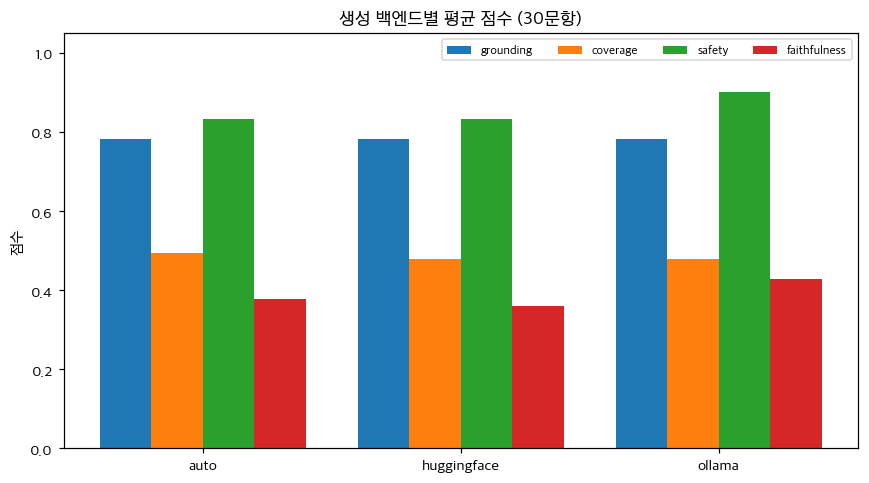

In [8]:
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np

# 한글 라벨이 네모(tofu)로 깨지지 않도록 macOS 한글 폰트를 명시적으로 등록한다.
_KOREAN_FONT_PATH = "/System/Library/Fonts/AppleSDGothicNeo.ttc"
if Path(_KOREAN_FONT_PATH).exists():
    fm.fontManager.addfont(_KOREAN_FONT_PATH)
    plt.rcParams["font.family"] = fm.FontProperties(fname=_KOREAN_FONT_PATH).get_name()
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110

modes = list(mode_means.index)
x = np.arange(len(modes))
width = 0.2

fig, ax = plt.subplots(figsize=(8, 4.5))
for offset, column in zip((-1.5, -0.5, 0.5, 1.5), SCORE_COLUMNS):
    ax.bar(x + offset * width, mode_means[column], width, label=column)
ax.set_xticks(x)
ax.set_xticklabels(modes)
ax.set_ylim(0, 1.05)
ax.set_ylabel("점수")
ax.set_title("생성 백엔드별 평균 점수 (30문항)")
ax.legend(ncol=4, fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "provider_scores.png")
plt.show()

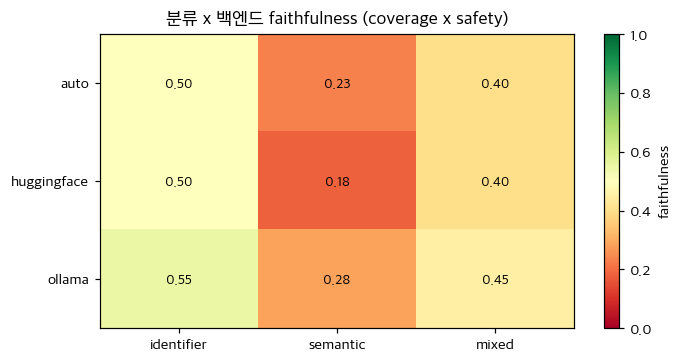

In [9]:
categories = ["identifier", "semantic", "mixed"]
heat = (
    ok.pivot_table(index="mode", columns="category", values="faithfulness", aggfunc="mean")
    .reindex(index=modes, columns=categories)
)

fig, ax = plt.subplots(figsize=(6.5, 3.4))
im = ax.imshow(heat.values, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(categories)))
ax.set_xticklabels(categories)
ax.set_yticks(range(len(modes)))
ax.set_yticklabels(modes)
for i in range(len(modes)):
    for j in range(len(categories)):
        value = heat.values[i, j]
        ax.text(j, i, "-" if np.isnan(value) else f"{value:.2f}", ha="center", va="center", fontsize=9)
ax.set_title("분류 x 백엔드 faithfulness (coverage x safety)")
fig.colorbar(im, ax=ax, label="faithfulness")
fig.tight_layout()
fig.savefig(FIG_DIR / "category_heatmap.png")
plt.show()

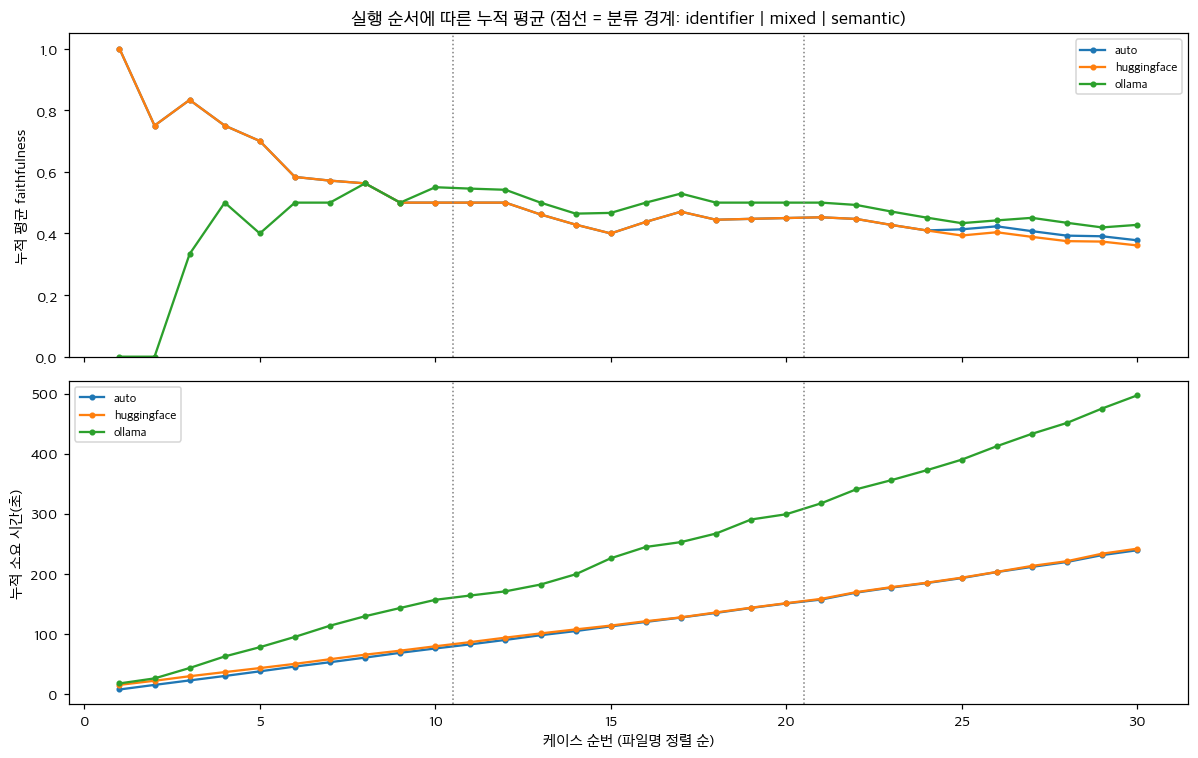

In [10]:
# 진행 상황 그래프. 케이스를 하나씩 돌리는 동안 점수가 어떻게 쌓였는지를 실행 순서대로 본다.
# 평균 한 칸으로는 "특정 분류 구간에서만 무너졌다"가 보이지 않는다.
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

for mode in modes:
    part = ok[ok["mode"] == mode].sort_values("order")
    running = part["faithfulness"].expanding().mean()
    axes[0].plot(part["order"], running, marker="o", markersize=3, label=mode)
    axes[1].plot(part["order"], part["elapsed_s"].cumsum(), marker="o", markersize=3, label=mode)

boundaries = [10.5, 20.5]
for axis in axes:
    for boundary in boundaries:
        axis.axvline(boundary, color="gray", linestyle=":", linewidth=1)
axes[0].set_ylabel("누적 평균 faithfulness")
axes[0].set_ylim(0, 1.05)
axes[0].set_title("실행 순서에 따른 누적 평균 (점선 = 분류 경계: identifier | mixed | semantic)")
axes[0].legend(fontsize=8)
axes[1].set_ylabel("누적 소요 시간(초)")
axes[1].set_xlabel("케이스 순번 (파일명 정렬 순)")
axes[1].legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "progress.png")
plt.show()

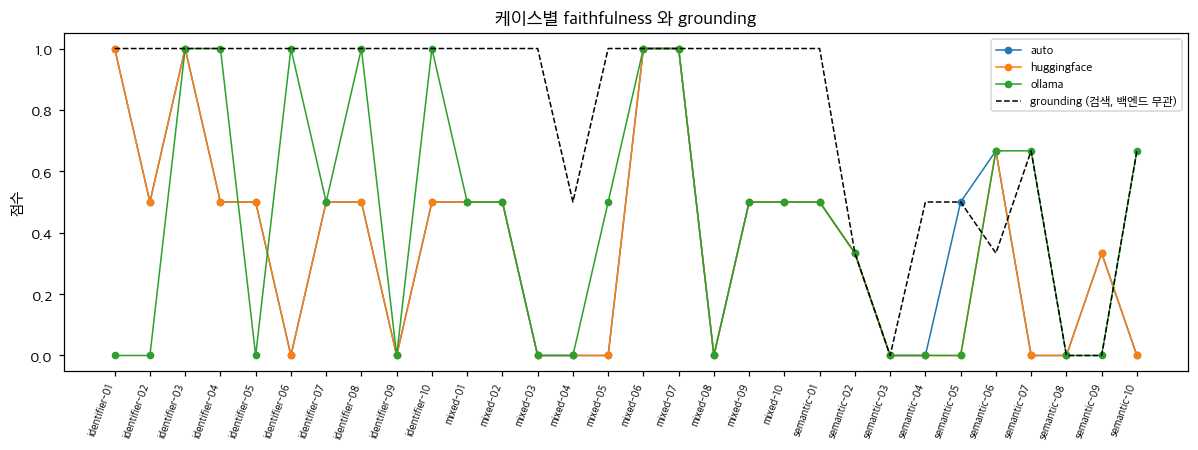

In [11]:
fig, ax = plt.subplots(figsize=(11, 4.2))
case_order = ok.sort_values("order")["case_id"].unique()
for mode in modes:
    part = ok[ok["mode"] == mode].set_index("case_id").reindex(case_order)
    ax.plot(range(len(case_order)), part["faithfulness"], marker="o", markersize=4, linewidth=1, label=mode)
ax.plot(
    range(len(case_order)),
    ok[ok["mode"] == modes[0]].set_index("case_id").reindex(case_order)["grounding"],
    color="black",
    linestyle="--",
    linewidth=1,
    label="grounding (검색, 백엔드 무관)",
)
ax.set_xticks(range(len(case_order)))
ax.set_xticklabels(case_order, rotation=70, ha="right", fontsize=7)
ax.set_ylim(-0.05, 1.05)
ax.set_ylabel("점수")
ax.set_title("케이스별 faithfulness 와 grounding")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "per_case_scores.png")
plt.show()

## 7. 원자료 저장

In [12]:
from datetime import date

stamp = date.today().strftime("%Y%m%d")
csv_path = DATA_DIR / f"runs_{stamp}.csv"
df.to_csv(csv_path, index=False, encoding="utf-8-sig")
print("저장:", csv_path, f"({len(df)} rows)")

summary_path = DATA_DIR / f"summary_{stamp}.csv"
summary = ok.groupby(["mode", "category"])[SCORE_COLUMNS].mean().round(3).reset_index()
summary.to_csv(summary_path, index=False, encoding="utf-8-sig")
print("저장:", summary_path)
print("\n측정 조건: 프로젝트", PROJECT_ID, "| 심사기", _JUDGE_MODEL, "| 모드", MEASURED_MODES)

저장: ~/Desktop/Python/Work-Flow-worktrees/issue-625/output/assistant_eval/data/runs_20260819.csv (90 rows)
저장: ~/Desktop/Python/Work-Flow-worktrees/issue-625/output/assistant_eval/data/summary_20260819.csv

측정 조건: 프로젝트 1 | 심사기 Qwen/Qwen3-4B-Instruct-2507 | 모드 ['huggingface', 'ollama', 'auto']


## 8. 읽는 법

- `grounding` 이 낮은 케이스는 생성이 아니라 **검색** 문제다. 백엔드를 바꿔도 거의 같은 값이
  나와야 정상이고, 모드마다 다르면 검색이 비결정적이라는 뜻이라 그것부터 본다.
- `coverage` 가 낮고 `grounding` 이 높으면 근거는 올라왔는데 답이 그걸 말하지 않은 것이다.
  프롬프트·모델 문제다.
- `safety` 가 낮으면 답이 근거에 없는 것을 특정했다는 뜻이다. `must_not_claim` 은 대부분
  "담당자를 특정한다"·"마감일을 특정한다" 형태라, 컨텍스트에 붙는 메타데이터
  (`task_facts_service.enrich_with_facts` 가 넣는 마감일·상태·우선순위)를 답변이 그대로
  옮겨 적으면 여기서 깎인다. 이 경우 점수가 낮은 것이 곧 결함이라고 단정하지 말고
  `answer` 열을 열어 확인한다.
- `unparsed` 가 0 이 아니면 그 모드의 `coverage`/`safety` 는 그만큼 근거가 약하다.

측정 결과 해석은 `output/assistant_eval/RESULT.md` 에 적는다.